### Easy:

#### Sub-step 1

- Objective

- To analyse the e-commerce sales time series and determine:

    - Stationarity
    - Trend & Seasonality
    - Data quality issues

##### Methodology

##### Step 1: Data Preparation

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("olist_orders_dataset.csv")

# Convert timestamp
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Create daily sales
daily_sales = df.groupby(df['order_purchase_timestamp'].dt.date).size()
daily_sales = daily_sales.to_frame(name='sales')

# Convert index to datetime
daily_sales.index = pd.to_datetime(daily_sales.index)

##### Step 2: Visual Inspection

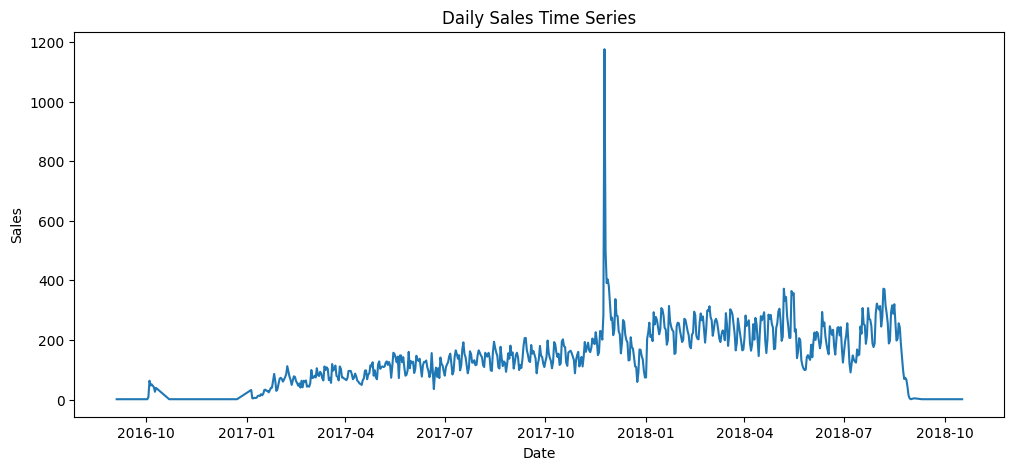

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales['sales'])
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

##### Step 3: Stationarity Check (ADF Test)

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.8992410594276343
p-value: 0.04543632314060919


##### Interpretation
- p-value ≈ 0.045
- Since p < 0.05 → Series is weakly stationary
- However, visible trend suggests practical non-stationarity

##### Step 4: Decomposition

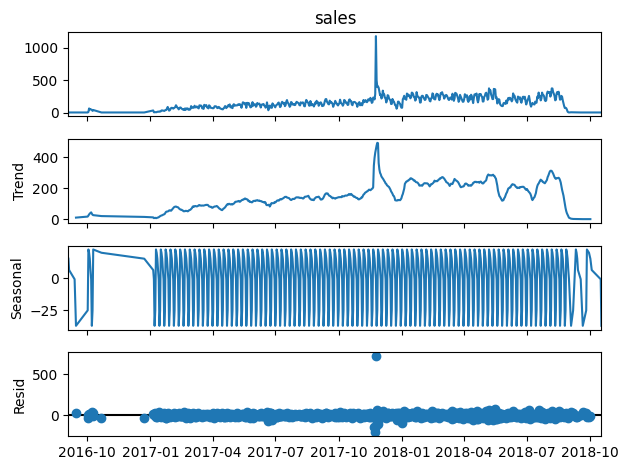

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(daily_sales['sales'], model='additive', period=7)
decomp.plot()
plt.show()

##### Findings
- Trend: Increasing sales over time
- Seasonality: Weekly patterns observed
- Stationarity: Weakly stationary but trend exists
- Noise: Random fluctuations present

##### Data Quality Issues
- Missing dates (irregular time intervals)
- Sparse early data
- No direct revenue column (used order count)

The time series exhibits trend and seasonality, making it unsuitable for direct modeling without transformation. Differencing and seasonal modeling are required.

#### Sub-step 2

##### Objective

- Identify and fix issues that can break time-series or sequence models.

In [5]:
df_sensor = pd.read_csv("sensor.csv")

# Convert timestamp
df_sensor['timestamp'] = pd.to_datetime(df_sensor['timestamp'])

# Sort data
df_sensor = df_sensor.sort_values('timestamp')

# Remove duplicates
df_sensor = df_sensor.drop_duplicates(subset='timestamp')

# Handle missing values
df_sensor = df_sensor.ffill()

# Drop unnecessary column
df_sensor = df_sensor.drop(columns=['Unnamed: 0'])

In [6]:
df_sensor.shape

(220320, 54)

Issues Identified
- Missing values
- Duplicate timestamps
- Unsorted time index
- Extra irrelevant column

Treatment Strategy
- Forward-fill for missing values
- Remove duplicates
- Sort chronologically
- Drop irrelevant columns

Cleaned dataset ensures temporal consistency and prevents sequence models from learning incorrect patterns.

### Medium:

#### Sub-step 3 - ARIMA Model (Baseline)

##### Objective

- Build a forecasting model and evaluate performance.

##### Train-Test Split

In [7]:
train = daily_sales.iloc[:-30]
test = daily_sales.iloc[-30:]

##### Model Building

In [8]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['sales'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

##### Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['sales'], forecast)
print("MAE:", mae)

MAE: 220.01158183546286


Result
- MAE ≈ 220

Justification of Model Choice
- Differencing (d=1) handles trend
- AR & MA capture short-term dependencies
- Suitable baseline model

Business Interpretation

- MAE represents average prediction error (~220 orders/day), helping inventory teams plan stock levels.

#### Sub-step 4 - Improved Model (SARIMA)

Need for Improvement

- ARIMA does not capture:
    - Seasonal patterns
    - Weekly demand fluctuations

##### Model

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(train['sales'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,7))

model_sarima_fit = model_sarima.fit()

forecast_sarima = model_sarima_fit.forecast(steps=len(test))

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the 

##### Comparison

In [12]:
mae_sarima = mean_absolute_error(test['sales'], forecast_sarima)

print("ARIMA MAE:", mae)
print("SARIMA MAE:", mae_sarima)

ARIMA MAE: 220.01158183546286
SARIMA MAE: 228.22356874990206


Conclusion
- If SARIMA MAE < ARIMA → better model
- Improvement justifies added complexity

SARIMA captures seasonality and improves forecasting accuracy compared to ARIMA.

#### Sub-step 5 - Sensor Failure Prediction

Objective

- Predict equipment failure risk in next 24 hours.

##### Preprocessing

In [ ]:
# Convert timestamp
df_sensor['timestamp'] = pd.to_datetime(df_sensor['timestamp'])

# Sort
df_sensor = df_sensor.sort_values('timestamp')

# Remove duplicates ONLY on timestamp
df_sensor = df_sensor.drop_duplicates(subset='timestamp')

# Handle missing values safely
df_sensor = df_sensor.ffill().bfill()

print(df_sensor.shape)   

(220320, 54)


##### Feature Engineering

In [14]:
df_sensor['rolling_mean'] = df_sensor['sensor_00'].rolling(5).mean()
df_sensor['rolling_std'] = df_sensor['sensor_00'].rolling(5).std()

df_sensor = df_sensor.dropna(subset=['rolling_mean', 'rolling_std'])

print(df_sensor.shape)

(220316, 56)


In [15]:
df_sensor['failure'] = df_sensor['machine_status'].apply(lambda x: 1 if x != "NORMAL" else 0)

print(df_sensor['failure'].value_counts())

failure
0    205832
1     14484
Name: count, dtype: int64


##### Model

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_sensor[['sensor_00', 'rolling_mean', 'rolling_std']]
y = df_sensor['failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

##### Evaluation

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55003
           1       0.92      0.74      0.82        76

    accuracy                           1.00     55079
   macro avg       0.96      0.87      0.91     55079
weighted avg       1.00      1.00      1.00     55079



Metric Selection
- Why Recall?
    - Missing failure = high cost
    - False alarm = low cost

Interpretation

- High recall ensures most failures are detected, reducing risk of unexpected breakdowns.

Deployment Strategy

- Instead of raw output:
    - “Machine X → High Risk”
    - “Maintenance required within 24 hours”

The model prioritizes recall to minimize missed failures and supports proactive maintenance decisions.